In [47]:
import umap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.append("../")
import utils as ut
from matplotlib.colors import ListedColormap
from matplotlib.ticker import MaxNLocator


In [48]:
# Define the colors
colors = [
    "#2e8b57",  #dark green
    "#1e3a8a",  #slightly brighter dark blue
    "#b22222",  #slightly brighter dark red
    "#ff8c00",  #dark yellow/orange
    "#696969",  #dark gray
    "#6a0dad",  #slightly brighter dark purple
    "#000000"   #black for DMSO
]
# Create the categorical colormap
cmap = ListedColormap(colors)

# MOA list linked to the colors
moa_list = ["AKT", "CDK", "HDAC", "MAPK", "PARP", "TUB", "dmso"]

color_map = {label: cmap(i) for i, label in enumerate(moa_list)}

In [59]:
cells = ['A549-WT', "U2OS-WT"]
reducer = umap.UMAP(n_components=2, n_neighbors=25, min_dist=0.1, metric='euclidean', random_state=42)
for i, cell in enumerate(cells):
    print(cell)
    df = pd.read_parquet(f'../../dino_feature_extraction/data/{cell}/dino_vitb14_features/{cell}-median_well_features.parquet.gzip')
    df = df[df['Metadata_cmpd_moa_group'] != 'undefined'].copy()
    df = df[df['Metadata_cmpd_moa_group'].notnull()].copy()
    df = df[df['Metadata_hours'].isin(incl_hours)].copy()
    # Sort df by MOA to ensure consistent color mapping
    df = df.sort_values(by='Metadata_cmpd_moa_group')
    feature_data = ut.get_featuredata(df)
    embedding = reducer.fit_transform(feature_data)
    embeddings.append(embedding)

A549-WT


/home/edvinf/LCTP/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/edvinf/LCTP/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


U2OS-WT


/home/edvinf/LCTP/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


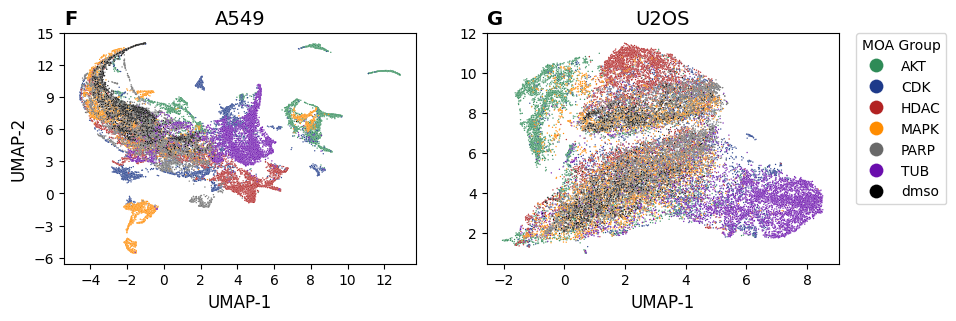

In [67]:
# plot, ax = plt.subplots(1, 2, figsize=(10, 3.5))
plot, ax = plt.subplots(1, 2, figsize=(10, 3))
incl_hours = np.arange(24, 74, 2)
left_title = ['F', 'G']
for i, cell in enumerate(cells):
    df = pd.read_parquet(f'../../dino_feature_extraction/data/{cell}/dino_vitb14_features/{cell}-median_well_features.parquet.gzip')
    df = df[df['Metadata_cmpd_moa_group'] != 'undefined'].copy()
    df = df[df['Metadata_cmpd_moa_group'].notnull()].copy()
    df = df[df['Metadata_hours'].isin(incl_hours)].copy()
    # Sort df by MOA to ensure consistent color mapping
    df = df.sort_values(by='Metadata_cmpd_moa_group')
    embedding = embeddings[i]
    if i == 0:
        sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=df['Metadata_cmpd_moa_group'], ax=ax[i], s=1, legend=False, palette=color_map)
    else:
        sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=df['Metadata_cmpd_moa_group'], ax=ax[i], s=1, legend=True, palette=color_map)

    if i > 0:
        # Adjust the position of the legend to be outside the plot
        ax[i].legend(title='MOA Group', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., markerscale=10)
    # Remove decimals from tick labels
    ax[i].xaxis.set_major_locator(MaxNLocator(integer=True))
    ax[i].yaxis.set_major_locator(MaxNLocator(integer=True))

    ax[i].set_title(f'{left_title[i]}', loc='left', fontsize=14, fontweight='bold')
    ax[i].set_title(f'{cell[:-3]}', loc='center', fontsize=14)
    if i ==0:
        ax[i].set_ylabel('UMAP-2', fontsize=12)
    ax[i].set_xlabel('UMAP-1', fontsize=12)
# plt.tight_layout()
plt.savefig('fig2F_G_umap_moa_groups.svg', bbox_inches='tight')
